# 1. Mô tả

- Xây dựng mô hình Linear Regression để làm baseline so sánh và 1 mô hình Regression khác.

- Trả lời câu hỏi: Dự đoán lương với 2 hypothesises đã được tạo trong file `04_preprocessing_feature_modeling.ipynb`.

# Import thư viện

In [2]:
# import các thư viện cần thiết
import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
DATA_DIR = Path("../data")


# Hàm phụ

In [2]:
# cài đặt các hàm cần thiết (các hàm tính metrics MSE, MAE, ....), các hàm cần thiết khác thì khai báo ở đây
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "mae": float(mae),
        "mse": float(mse),
        "rmse": rmse,
        "r2": float(r2),
    }


def fit_and_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_m = {f"train_{k}": v for k, v in regression_metrics(y_train, pred_train).items()}
    test_m = {f"test_{k}": v for k, v in regression_metrics(y_test, pred_test).items()}

    return {
        "model": model_name,
        **train_m,
        **test_m,
    }


def results_to_table(results):
    df_res = pd.DataFrame(results).copy()
    metric_cols = [c for c in df_res.columns if c != "model"]
    df_res = df_res[["model"] + metric_cols]

    # format cho dễ đọc
    for c in metric_cols:
        if "r2" in c:
            df_res[c] = df_res[c].map(lambda x: f"{x:.4f}")
        else:
            df_res[c] = df_res[c].map(lambda x: f"{x:,.2f}")
    return df_res


def plot_pred_vs_true(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.35)
    min_v = float(min(np.min(y_true), np.min(y_pred)))
    max_v = float(max(np.max(y_true), np.max(y_pred)))
    plt.plot([min_v, max_v], [min_v, max_v], color="red", linewidth=2)
    plt.title(title)
    plt.xlabel("True salary_in_usd")
    plt.ylabel("Predicted salary_in_usd")
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(7, 4))
    sns.histplot(residuals, bins=40, kde=True)
    plt.title(title)
    plt.xlabel("Residual = y_true - y_pred")
    plt.tight_layout()
    plt.show()


def linear_feature_effects(lr_model, feature_names, top_n=15):
    coefs = pd.DataFrame({
        "feature": feature_names,
        "coef": lr_model.coef_
    })
    coefs["abs_coef"] = coefs["coef"].abs()
    coefs = coefs.sort_values("abs_coef", ascending=False).drop(columns=["abs_coef"])
    return coefs.head(top_n)


def xgb_feature_importance(xgb_model, feature_names, top_n=15):
    imps = pd.DataFrame({
        "feature": feature_names,
        "importance": xgb_model.feature_importances_
    }).sort_values("importance", ascending=False)
    return imps.head(top_n)


# 2. Linear Regression

## 2.1 Lý thuyết Linear Regression 

**Bài toán & mục tiêu**

Với dữ liệu $(x^{(i)}, y^{(i)})$ trong đó $y$ là biến liên tục (ở đây là `salary_in_usd`), Linear Regression tìm một hàm tuyến tính để dự đoán $y$ từ các đặc trưng $x$ sao cho sai số dự đoán là nhỏ nhất.

**Mô hình toán học**

Với $p$ đặc trưng, mô hình hồi quy tuyến tính đa biến:

$$\hat{y} = h_\theta(x) = \theta_0 + \theta_1 x_1 + \cdots + \theta_p x_p$$

Viết gọn theo vector:

$$\hat{y} = X\theta$$

Trong đó:
- $X \in \mathbb{R}^{n \times (p+1)}$ là ma trận thiết kế (có thêm cột 1 cho bias),
- $\theta \in \mathbb{R}^{p+1}$ là vector hệ số,
- $\hat{y}$ là giá trị dự đoán.

**Hàm mất mát và nguyên lý OLS**

Phổ biến nhất là **Ordinary Least Squares (OLS)**: tối thiểu hóa tổng bình phương sai số:

$$J(\theta) = \frac{1}{n}\sum_{i=1}^{n}\left(y^{(i)} - \hat{y}^{(i)}\right)^2 = \frac{1}{n}\|y - X\theta\|_2^2$$

Nghiệm đóng (khi $X^TX$ khả nghịch):

$$\theta^{\star} = (X^{T}X)^{-1}X^{T}y$$

Thực tế trong thư viện scikit-learn, việc giải thường dùng các thuật toán số ổn định (ví dụ SVD), không nhất thiết tính nghịch đảo trực tiếp.


**Các giả định quan trọng (để diễn giải tốt hơn)**

Linear Regression thường được diễn giải tốt nhất khi các giả định gần đúng:
- Quan hệ tuyến tính (hoặc tuyến tính theo tham số) giữa $X$ và $y$
- Sai số độc lập (independence)
- Phương sai sai số gần như không đổi (homoscedasticity)
- Sai số có phân phối gần chuẩn (chủ yếu để suy luận thống kê; dự đoán vẫn dùng được khi lệch chuẩn ở mức vừa)

**Điểm mạnh**

- Đơn giản, huấn luyện nhanh, baseline tốt
- Dễ giải thích (hệ số, dấu tác động)
- Ít hyperparameter, dễ tái lập
- Hoạt động tốt khi quan hệ thật sự gần tuyến tính

**Hạn chế**

- Khó bắt được quan hệ phi tuyến/phức tạp (tương tác mạnh, ngưỡng, “bậc thang”)
- Nhạy với outliers (vì bình phương sai số)
- Dễ bị đa cộng tuyến (các biến tương quan mạnh) làm hệ số kém ổn định
- Hiệu năng có thể thua các mô hình mạnh hơn (tree boosting như XGBoost) khi dữ liệu có cấu trúc phi tuyến

## 2.2 Đọc dữ liệu

In [3]:
# Đọc cho cả 2 hypothesis train, test.

train_h1_path = DATA_DIR / "train_hypo_1.csv"
test_h1_path  = DATA_DIR / "test_hypo_1.csv"
train_h2_path = DATA_DIR / "train_hypo_2.csv"
test_h2_path  = DATA_DIR / "test_hypo_2.csv"

train_h1 = pd.read_csv(train_h1_path)
test_h1  = pd.read_csv(test_h1_path)
train_h2 = pd.read_csv(train_h2_path)
test_h2  = pd.read_csv(test_h2_path)

def split_xy(df, target="salary_in_usd"):
    X = df.drop(columns=[target])
    y = df[target]
    return X, y

X_train_h1, y_train_h1 = split_xy(train_h1)
X_test_h1,  y_test_h1  = split_xy(test_h1)

X_train_h2, y_train_h2 = split_xy(train_h2)
X_test_h2,  y_test_h2  = split_xy(test_h2)

print("H1 train/test:", train_h1.shape, test_h1.shape)
print("H2 train/test:", train_h2.shape, test_h2.shape)

print("\nH1 feature columns:", list(X_train_h1.columns))
print("\nH2 feature columns (first 20):", list(X_train_h2.columns)[:20], "… total:", X_train_h2.shape[1])

# Sanity: train/test phải có cùng feature columns
assert list(X_train_h1.columns) == list(X_test_h1.columns), "H1 train/test feature columns mismatch"
assert list(X_train_h2.columns) == list(X_test_h2.columns), "H2 train/test feature columns mismatch"



display(train_h1.head())
display(train_h2.head())

H1 train/test: (41949, 4) (10488, 4)
H2 train/test: (41949, 10) (10488, 10)

H1 feature columns: ['work_year', 'experience_level_encoded', 'is_US_company']

H2 feature columns (first 20): ['work_year', 'experience_level_encoded', 'company_size_encoded', 'remote_ratio', 'job_Data_Engineer', 'job_Data_Scientist', 'job_ML_AI_Engineer', 'job_Manager_Lead', 'job_Other'] … total: 9


,work_year,experience_level_encoded,is_US_company,salary_in_usd
0,2024,2,0,130000
1,2025,0,0,38724
2,2025,1,1,138810
3,2025,1,1,85300
4,2024,2,1,149469


,work_year,experience_level_encoded,company_size_encoded,remote_ratio,job_Data_Engineer,job_Data_Scientist,job_ML_AI_Engineer,job_Manager_Lead,job_Other,salary_in_usd
0,2024,2,1,0,0,1,0,0,0,130000
1,2025,0,1,0,1,0,0,0,0,38724
2,2025,1,1,0,0,0,0,0,0,138810
3,2025,1,1,100,0,1,0,0,0,85300
4,2024,2,1,0,1,0,0,0,0,149469


## 2.3 Huấn luyện mô hình

### fit mô hình

In [4]:
# fit mô hình với 2 hypotheses

lr_h1 = LinearRegression()
lr_h2 = LinearRegression()

lr_h1.fit(X_train_h1, y_train_h1)
lr_h2.fit(X_train_h2, y_train_h2)


print("H1: n_features =", X_train_h1.shape[1], "| train R2 =", lr_h1.score(X_train_h1, y_train_h1))
print("H2: n_features =", X_train_h2.shape[1], "| train R2 =", lr_h2.score(X_train_h2, y_train_h2))

H1: n_features = 3 | train R2 = 0.15620604728681153
H2: n_features = 9 | train R2 = 0.16074421063282163


### Đánh giá mô hình

,model,train_mae,train_mse,train_rmse,train_r2,test_mae,test_mse,test_rmse,test_r2
0,LinearRegression - H1,"52,325.80","5,086,470,573.34","71,319.50",0.1562,"52,503.12","5,154,680,747.68","71,796.11",0.1649
1,LinearRegression - H2,"52,339.22","5,059,114,091.06","71,127.45",0.1607,"52,387.37","5,139,199,983.23","71,688.21",0.1674


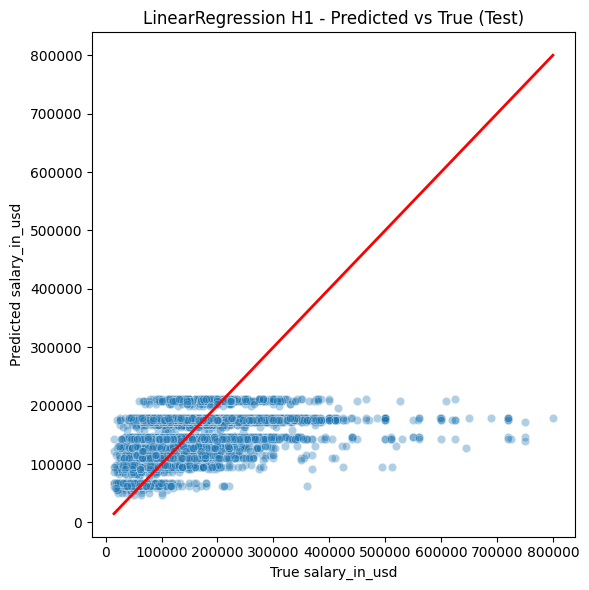

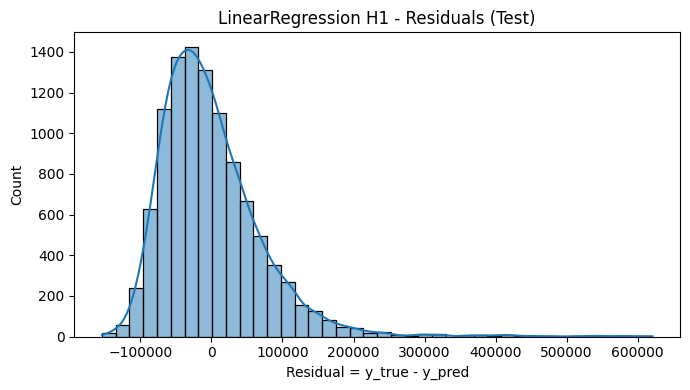

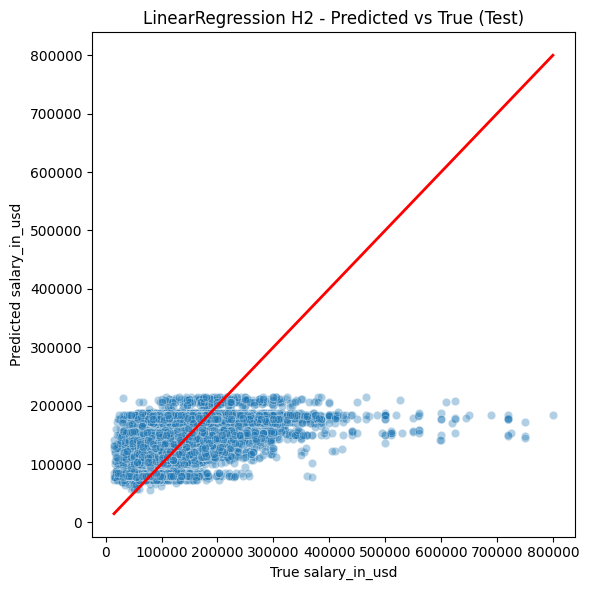

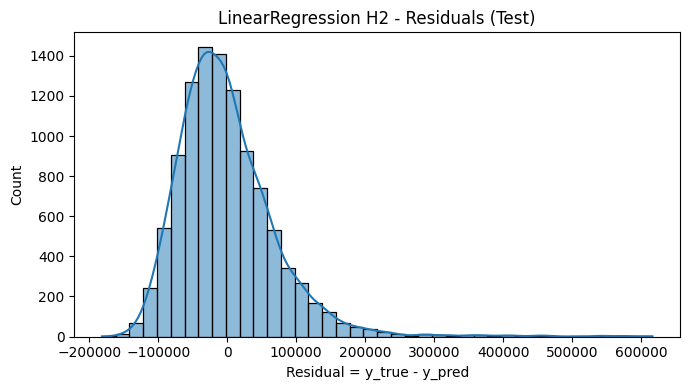

Top coefficients | H1


,feature,coef
2,is_US_company,48281.375226
1,experience_level_encoded,32026.005844
0,work_year,3941.867357


Top coefficients | H2


,feature,coef
7,job_Manager_Lead,45918.020058
5,job_Data_Scientist,42820.477378
4,job_Data_Engineer,42206.376525
1,experience_level_encoded,28321.855910
6,job_ML_AI_Engineer,25296.171659
0,work_year,5684.893373
8,job_Other,4114.128366
2,company_size_encoded,-3114.514086
3,remote_ratio,-71.141023


In [5]:
# 1) Tính metrics (train & test) cho 2 hypotheses
results = []
results.append(fit_and_evaluate(lr_h1, X_train_h1, y_train_h1, X_test_h1, y_test_h1, "LinearRegression - H1"))
results.append(fit_and_evaluate(lr_h2, X_train_h2, y_train_h2, X_test_h2, y_test_h2, "LinearRegression - H2"))

display(results_to_table(results))

# 2) Dự đoán để vẽ plot
pred_train_h1 = lr_h1.predict(X_train_h1)
pred_test_h1  = lr_h1.predict(X_test_h1)

pred_train_h2 = lr_h2.predict(X_train_h2)
pred_test_h2  = lr_h2.predict(X_test_h2)

# 3) Plot: Pred vs True + Residuals (ưu tiên test set)
plot_pred_vs_true(y_test_h1, pred_test_h1, "LinearRegression H1 - Predicted vs True (Test)")
plot_residuals(y_test_h1, pred_test_h1, "LinearRegression H1 - Residuals (Test)")

plot_pred_vs_true(y_test_h2, pred_test_h2, "LinearRegression H2 - Predicted vs True (Test)")
plot_residuals(y_test_h2, pred_test_h2, "LinearRegression H2 - Residuals (Test)")

# 4) Interpret features: hệ số Linear Regression (lưu ý: so sánh coef giữa các feature chỉ thật sự hợp lý khi feature cùng scale)
print("Top coefficients | H1")
display(linear_feature_effects(lr_h1, X_train_h1.columns, top_n=20))

print("Top coefficients | H2")
display(linear_feature_effects(lr_h2, X_train_h2.columns, top_n=20))

In [6]:
# Giả bộ dùng AI tạo 5 mẫu thử rồi đưa cho 2 mô hình dự đoán xem kết quả
# (Tạo 5 mẫu cho H1 + 5 mẫu cho H2, predict bằng Linear Regression, và lưu để dùng lại cho XGBoost)

# -------------------------
# A) Hypothesis 1 (H1)
# Features H1: work_year, experience_level_encoded, is_US_company
# -------------------------
X_demo_h1 = pd.DataFrame(
    [
        {"work_year": 2025, "experience_level_encoded": 0, "is_US_company": 0},  # EN, non-US
        {"work_year": 2025, "experience_level_encoded": 0, "is_US_company": 1},  # EN, US
        {"work_year": 2024, "experience_level_encoded": 2, "is_US_company": 0},  # SE, non-US
        {"work_year": 2024, "experience_level_encoded": 2, "is_US_company": 1},  # SE, US
        {"work_year": 2023, "experience_level_encoded": 3, "is_US_company": 1},  # EX, US
    ]
)

# đảm bảo đúng thứ tự cột như lúc train
X_demo_h1 = X_demo_h1[X_train_h1.columns]
pred_demo_lr_h1 = lr_h1.predict(X_demo_h1)

demo_lr_h1_table = X_demo_h1.copy()
demo_lr_h1_table["pred_salary_in_usd_lr"] = np.round(pred_demo_lr_h1, 2)

print("=== Demo predictions | Linear Regression | H1 (5 samples) ===")
display(demo_lr_h1_table)

# -------------------------
# B) Hypothesis 2 (H2)
# Features H2: work_year, experience_level_encoded, company_size_encoded, remote_ratio + job_* dummies
# (H2 có nhiều cột job dummy, nên ta auto tạo row đúng schema)
# -------------------------
h2_cols = list(X_train_h2.columns)
job_cols = [c for c in h2_cols if c.startswith("job_")]

base_row_h2 = {c: 0 for c in h2_cols}

def make_h2_sample(work_year, experience_level_encoded, company_size_encoded, remote_ratio, job_dummy_col=None):
    row = base_row_h2.copy()
    row["work_year"] = int(work_year)
    row["experience_level_encoded"] = int(experience_level_encoded)
    row["company_size_encoded"] = int(company_size_encoded)
    row["remote_ratio"] = int(remote_ratio)

    # set 1 dummy job nếu có (nếu None => baseline category do drop_first=True)
    if job_dummy_col is not None and job_dummy_col in row:
        row[job_dummy_col] = 1
    return row

# chọn 4 job dummy đầu tiên (nếu có) + 1 mẫu baseline
chosen_job_dummies = [None] + job_cols[:4]
while len(chosen_job_dummies) < 5:
    chosen_job_dummies.append(None)

X_demo_h2 = pd.DataFrame(
    [
        make_h2_sample(2025, 0, 0, 0,   chosen_job_dummies[0]),  # EN, S, onsite
        make_h2_sample(2025, 1, 1, 50,  chosen_job_dummies[1]),  # MI, M, hybrid
        make_h2_sample(2024, 2, 2, 100, chosen_job_dummies[2]),  # SE, L, remote
        make_h2_sample(2024, 3, 2, 0,   chosen_job_dummies[3]),  # EX, L, onsite
        make_h2_sample(2023, 2, 1, 100, chosen_job_dummies[4]),  # SE, M, remote
    ],
    columns=h2_cols,  # đảm bảo đúng schema ngay từ đầu
)

pred_demo_lr_h2 = lr_h2.predict(X_demo_h2)

demo_lr_h2_table = pd.DataFrame(
    {
        "work_year": X_demo_h2["work_year"],
        "experience_level_encoded": X_demo_h2["experience_level_encoded"],
        "company_size_encoded": X_demo_h2["company_size_encoded"],
        "remote_ratio": X_demo_h2["remote_ratio"],
        "job_dummy_used": [
            (x if x is not None else "baseline(drop_first)") for x in chosen_job_dummies
        ],
        "pred_salary_in_usd_lr": np.round(pred_demo_lr_h2, 2),
    }
)

print("=== Demo predictions | Linear Regression | H2 (5 samples) ===")
display(demo_lr_h2_table)

# -------------------------
# C) Lưu lại để dùng cho XGBoost về sau
# -------------------------
demo_h1_path = DATA_DIR / "demo_X_h1.csv"
demo_h2_path = DATA_DIR / "demo_X_h2.csv"
demo_pred_path = DATA_DIR / "demo_preds_lr.csv"

X_demo_h1.to_csv(demo_h1_path, index=False)
X_demo_h2.to_csv(demo_h2_path, index=False)

pd.DataFrame(
    {
        "hypothesis": ["H1"] * len(pred_demo_lr_h1) + ["H2"] * len(pred_demo_lr_h2),
        "sample_id": list(range(1, 6)) + list(range(1, 6)),
        "pred_salary_in_usd_lr": np.round(np.concatenate([pred_demo_lr_h1, pred_demo_lr_h2]), 2),
    }
).to_csv(demo_pred_path, index=False)

print("Saved:", demo_h1_path)
print("Saved:", demo_h2_path)
print("Saved:", demo_pred_path)

=== Demo predictions | Linear Regression | H1 (5 samples) ===


,work_year,experience_level_encoded,is_US_company,pred_salary_in_usd_lr
0,2025,0,0,66827.10
1,2025,0,1,115108.47
2,2024,2,0,126937.24
3,2024,2,1,175218.62
4,2023,3,1,203302.76


=== Demo predictions | Linear Regression | H2 (5 samples) ===


,work_year,experience_level_encoded,company_size_encoded,remote_ratio,job_dummy_used,pred_salary_in_usd_lr
0,2025,0,0,0,baseline(drop_first),87731.99
1,2025,1,1,50,job_Data_Engineer,151588.66
2,2024,2,2,100,job_Data_Scientist,168168.15
3,2024,3,2,0,job_ML_AI_Engineer,186079.81
4,2023,2,1,100,job_Manager_Lead,168695.32


Saved: ..\data\demo_X_h1.csv
Saved: ..\data\demo_X_h2.csv
Saved: ..\data\demo_preds_lr.csv


Cũng ổn ấy chứ 

## 2.4 Nhận xét (Linear Regression)

### (1) So sánh kết quả H1 vs H2 theo các metrics
Từ bảng kết quả:

- **H1**
  - Train: MAE ≈ 52,325.80 | RMSE ≈ 71,319.50 | $R^2$ ≈ 0.1562  
  - Test:  MAE ≈ 52,503.12 | RMSE ≈ 71,796.11 | $R^2$ ≈ 0.1649  

- **H2**
  - Train: MAE ≈ 52,339.22 | RMSE ≈ 71,127.45 | $R^2$ ≈ 0.1607  
  - Test:  MAE ≈ 52,387.37 | RMSE ≈ 71,688.21 | $R^2$ ≈ 0.1674  

**Nhận xét nhanh:**
- H2 **nhỉnh hơn rất nhẹ** so với H1 trên **test set** (MAE giảm nhẹ, RMSE giảm nhẹ, $R^2$ tăng nhẹ).
- Chênh lệch không lớn ⇒ việc thêm các biến (job role, size, remote, …) **có cải thiện nhưng chưa đáng kể** với mô hình tuyến tính hiện tại.

### (2) Overfitting / Underfitting?
- Train và Test có kết quả gần nhau (RMSE/MAE và $R^2$ không chênh nhiều) ⇒ **không có dấu hiệu overfitting mạnh**.
- Tuy nhiên $R^2$ chỉ khoảng **0.16–0.17** ⇒ mô hình đang **underfitting** (chưa giải thích được phần lớn biến thiên lương).

### (3) Nhìn từ biểu đồ Predicted vs True và Residuals
- Scatter Predicted vs True cho thấy nhiều điểm **không bám sát đường chéo**; dự đoán có xu hướng “bị kéo về vùng trung bình” (khó dự đoán đúng các mức lương quá cao/thấp).
- Residuals lệch và có đuôi dài (đặc biệt phía dương) ⇒ mô hình thường **dự đoán thấp hơn thực tế** ở các trường hợp lương rất cao (outliers/high-salary).

### (4) Diễn giải feature (hệ số) và mức độ hợp lý
**H1 (3 biến)**
- `is_US_company` có hệ số lớn nhất (+) ⇒ công ty ở Mỹ làm lương tăng mạnh (phù hợp với EDA/thực tế).
- `experience_level_encoded` (+) ⇒ kinh nghiệm càng cao, lương càng tăng (hợp lý).
- `work_year` (+) ⇒ lương tăng theo thời gian (phù hợp xu hướng lạm phát/nhu cầu).

**H2 (thêm job group, size, remote)**
- Các nhóm nghề như `job_Manager_Lead`, `job_Data_Scientist`, `job_Data_Engineer` có hệ số dương lớn ⇒ các role này thường trả cao hơn nhóm baseline (hợp lý).
- `company_size_encoded` ra hệ số âm và `remote_ratio` gần 0/âm nhẹ: điều này **có thể xảy ra** vì:
  - dữ liệu thật sự không cho thấy hiệu ứng tuyến tính rõ,
  - hoặc do tương quan giữa các biến (đa cộng tuyến) làm hệ số “đổi dấu” khi các biến cùng xuất hiện.

> Lưu ý: so sánh độ lớn hệ số giữa các feature chỉ thực sự công bằng khi feature cùng thang đo; ở đây các biến có scale khác nhau nên nên tập trung vào **dấu** và ý nghĩa tổng quát.

### (5) Kết luận về 2 giả thuyết (với Linear Regression)
- **Cả H1 và H2 đều chưa đủ tốt** nếu mục tiêu là dự đoán chính xác cao (vì $R^2$ thấp).
- **H2 tốt hơn H1 một chút**, cho thấy thêm thông tin về **role** có ích, nhưng mô hình tuyến tính vẫn không nắm được các quan hệ phức tạp.

### (6) Vì sao kết quả chưa cao? Có thể thiếu gì?
Một số khả năng:
- Quan hệ giữa lương và các biến có thể **phi tuyến** và có **tương tác** (ví dụ: role × quốc gia × kinh nghiệm).
- Phân phối `salary_in_usd` thường lệch phải và có outliers ⇒ Linear Regression dễ bị ảnh hưởng.
- Feature engineering còn đơn giản: chưa dùng `employee_residence`, `employment_type`, `company_location` đầy đủ (ngoài US/non-US), hoặc chưa xử lý outliers/log-transform.

**Hướng đi tiếp theo**
Vì các dấu hiệu trên, nhóm sẽ thử mô hình phi tuyến mạnh hơn như **XGBoost** và có bước **hyperparameter tuning** để cải thiện performance.

# 3. XGBoost 

## 3.1 Lý thuyết & mục tiêu

### XGBoost Regression là gì?
**XGBoost (Extreme Gradient Boosting)** là mô hình boosting trên cây quyết định. Thay vì dùng 1 mô hình đơn giản (như Linear Regression), XGBoost xây dựng **nhiều cây** theo kiểu “học dần từ sai số”:
- Ở mỗi vòng, mô hình thêm một cây mới để giảm phần lỗi còn lại của mô hình trước đó.
- Vì là cây quyết định, XGBoost có thể học **quan hệ phi tuyến** và **tương tác giữa các biến** (ví dụ: role × kinh nghiệm × năm).

### Vì sao dùng XGBoost ở bài này?
Ở Linear Regression, $R^2$ thấp (~0.16–0.17) cho thấy mô hình tuyến tính **underfitting**. Dữ liệu lương thường:
- có phân phối lệch + outliers,
- có nhiều tương tác,
- không thuần tuyến tính theo từng feature.
=> XGBoost thường là lựa chọn mạnh để cải thiện dự đoán.

### Mục tiêu thực nghiệm
- Huấn luyện **XGBRegressor** cho cả 2 giả thuyết (H1 và H2).
- Đánh giá bằng các metrics giống Linear Regression: MAE, RMSE, $R^2$ (train/test).
- Thực hiện **hyperparameter tuning** (GridSearchCV) để chọn bộ tham số tốt hơn baseline.
- Dùng lại 10 mẫu demo (đã lưu) để dự đoán và so sánh với Linear Regression.

## 3.2 XGBoost baseline

In [ ]:
# XGBoost baseline (chưa tuning)

xgb_h1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

xgb_h2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

results_xgb = []
results_xgb.append(fit_and_evaluate(xgb_h1, X_train_h1, y_train_h1, X_test_h1, y_test_h1, "XGBoost (baseline) - H1"))
results_xgb.append(fit_and_evaluate(xgb_h2, X_train_h2, y_train_h2, X_test_h2, y_test_h2, "XGBoost (baseline) - H2"))

print("=== XGBoost baseline | Metrics (train/test) ===")
display(results_to_table(results_xgb))

# lưu predictions để lát vẽ plot và so sánh
pred_train_xgb_h1 = xgb_h1.predict(X_train_h1)
pred_test_xgb_h1  = xgb_h1.predict(X_test_h1)

pred_train_xgb_h2 = xgb_h2.predict(X_train_h2)
pred_test_xgb_h2  = xgb_h2.predict(X_test_h2)

=== XGBoost baseline | Metrics (train/test) ===


,model,train_mae,train_mse,train_rmse,train_r2,test_mae,test_mse,test_rmse,test_r2
0,XGBoost (baseline) - H1,"52,242.81","5,070,421,504.00","71,206.89",0.1589,"52,474.00","5,147,531,776.00","71,746.30",0.1661
1,XGBoost (baseline) - H2,"51,476.35","4,941,874,688.00","70,298.47",0.1802,"52,034.71","5,092,249,088.00","71,360.00",0.1750


Done. Stored preds: pred_test_xgb_h1, pred_test_xgb_h2


## 3.3 XGBoost baseline: Plots + Feature Importance

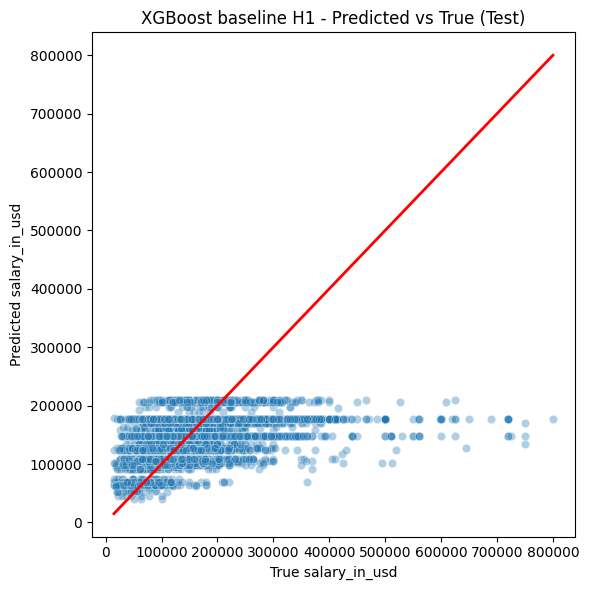

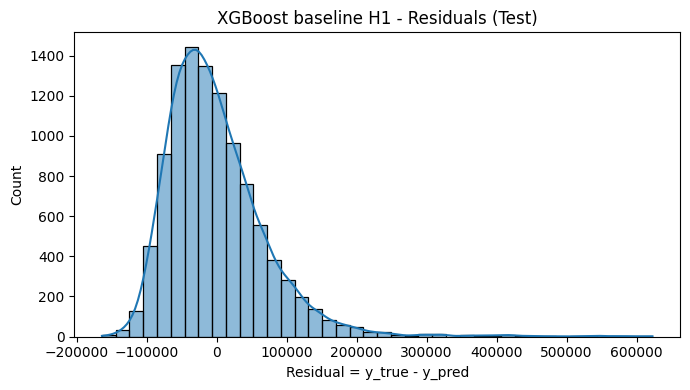

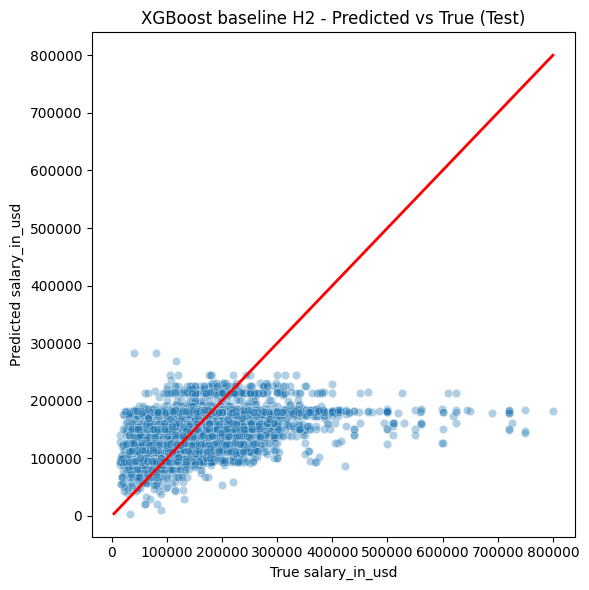

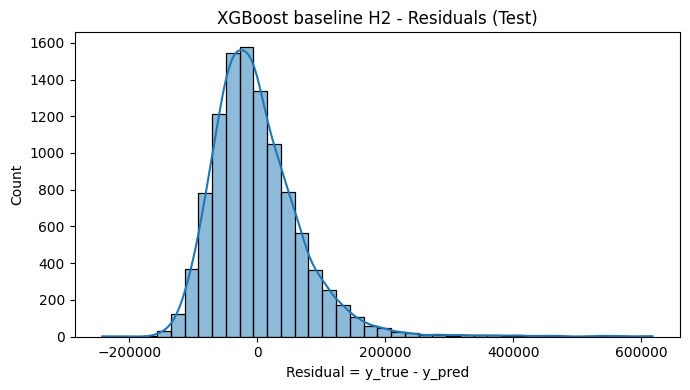

Top feature importance | XGBoost baseline H1


,feature,importance
2,is_US_company,0.580678
1,experience_level_encoded,0.406868
0,work_year,0.012454


Top feature importance | XGBoost baseline H2


,feature,importance
1,experience_level_encoded,0.263995
5,job_Data_Scientist,0.195543
7,job_Manager_Lead,0.189981
4,job_Data_Engineer,0.177711
8,job_Other,0.097763
6,job_ML_AI_Engineer,0.021591
0,work_year,0.021183
3,remote_ratio,0.018483
2,company_size_encoded,0.013750


In [8]:
# 3.3 XGBoost baseline: Plots + Feature Importance

# --- Plots (ưu tiên test set) ---
plot_pred_vs_true(y_test_h1, pred_test_xgb_h1, "XGBoost baseline H1 - Predicted vs True (Test)")
plot_residuals(y_test_h1, pred_test_xgb_h1, "XGBoost baseline H1 - Residuals (Test)")

plot_pred_vs_true(y_test_h2, pred_test_xgb_h2, "XGBoost baseline H2 - Predicted vs True (Test)")
plot_residuals(y_test_h2, pred_test_xgb_h2, "XGBoost baseline H2 - Residuals (Test)")

# --- Feature importance ---
print("Top feature importance | XGBoost baseline H1")
display(xgb_feature_importance(xgb_h1, X_train_h1.columns, top_n=20))

print("Top feature importance | XGBoost baseline H2")
display(xgb_feature_importance(xgb_h2, X_train_h2.columns, top_n=20))

## 3.4 Hyperparameter tuning (GridSearchCV)

In [9]:
# Lưu ý: GridSearchCV dùng CV trên TRAIN SET, sau đó mình đánh giá lại trên TEST SET để so sánh công bằng.
# Scoring: tối ưu RMSE (neg_root_mean_squared_error => càng "ít âm" càng tốt)

# --- H1 tuning grid (nhỏ vừa để chạy được) ---
xgb_base_h1 = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

param_grid_h1 = {
    "n_estimators": [300, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "reg_lambda": [1.0, 5.0],
}

grid_h1 = GridSearchCV(
    estimator=xgb_base_h1,
    param_grid=param_grid_h1,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_h1.fit(X_train_h1, y_train_h1)
best_xgb_h1 = grid_h1.best_estimator_

print("=== Best params | H1 ===")
print(grid_h1.best_params_)
print("Best CV RMSE (H1):", round(-grid_h1.best_score_, 4))

# --- H2 tuning grid (nhẹ hơn vì số feature lớn hơn) ---
xgb_base_h2 = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

param_grid_h2 = {
    "n_estimators": [300, 600],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "reg_lambda": [1.0, 5.0],
}

grid_h2 = GridSearchCV(
    estimator=xgb_base_h2,
    param_grid=param_grid_h2,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_h2.fit(X_train_h2, y_train_h2)
best_xgb_h2 = grid_h2.best_estimator_

print("\n=== Best params | H2 ===")
print(grid_h2.best_params_)
print("Best CV RMSE (H2):", round(-grid_h2.best_score_, 4))

# --- Đánh giá best models trên train/test giống Linear Regression ---
results_xgb_tuned = []
results_xgb_tuned.append(
    fit_and_evaluate(best_xgb_h1, X_train_h1, y_train_h1, X_test_h1, y_test_h1, "XGBoost (tuned) - H1")
)
results_xgb_tuned.append(
    fit_and_evaluate(best_xgb_h2, X_train_h2, y_train_h2, X_test_h2, y_test_h2, "XGBoost (tuned) - H2")
)

print("\n=== XGBoost tuned | Metrics (train/test) ===")
display(results_to_table(results_xgb_tuned))

# Lưu predictions tuned để lát vẽ plot & dùng dự đoán demo samples
pred_test_xgb_tuned_h1 = best_xgb_h1.predict(X_test_h1)
pred_test_xgb_tuned_h2 = best_xgb_h2.predict(X_test_h2)

print("Done. Stored preds: pred_test_xgb_tuned_h1, pred_test_xgb_tuned_h2")

Fitting 3 folds for each of 192 candidates, totalling 576 fits
=== Best params | H1 ===
{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300, 'reg_lambda': 5.0, 'subsample': 0.8}
Best CV RMSE (H1): 71230.7135
Fitting 3 folds for each of 128 candidates, totalling 384 fits

=== Best params | H2 ===
{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 600, 'reg_lambda': 5.0, 'subsample': 0.8}
Best CV RMSE (H2): 70666.7812

=== XGBoost tuned | Metrics (train/test) ===


,model,train_mae,train_mse,train_rmse,train_r2,test_mae,test_mse,test_rmse,test_r2
0,XGBoost (tuned) - H1,"52,220.56","5,068,039,680.00","71,190.17",0.1593,"52,450.23","5,144,821,248.00","71,727.41",0.1665
1,XGBoost (tuned) - H2,"51,719.68","4,973,064,192.00","70,519.96",0.1750,"51,979.79","5,077,009,920.00","71,253.14",0.1775


Done. Stored preds: pred_test_xgb_tuned_h1, pred_test_xgb_tuned_h2


## 3.5 So sánh baseline vs tuned

In [10]:
# --- A) So sánh metrics (baseline vs tuned) trong 1 bảng ---
compare_all = results_xgb + results_xgb_tuned
print("=== Compare XGBoost baseline vs tuned | Metrics (train/test) ===")
display(results_to_table(compare_all))

# --- B) Load 10 demo samples đã lưu từ Linear Regression ---
demo_h1_path = DATA_DIR / "demo_X_h1.csv"
demo_h2_path = DATA_DIR / "demo_X_h2.csv"

X_demo_h1_loaded = pd.read_csv(demo_h1_path)
X_demo_h2_loaded = pd.read_csv(demo_h2_path)

# đảm bảo đúng thứ tự cột train
X_demo_h1_loaded = X_demo_h1_loaded[X_train_h1.columns]
X_demo_h2_loaded = X_demo_h2_loaded[X_train_h2.columns]

# --- C) Predict demo samples bằng XGBoost baseline và tuned ---
pred_demo_xgb_base_h1 = xgb_h1.predict(X_demo_h1_loaded)
pred_demo_xgb_base_h2 = xgb_h2.predict(X_demo_h2_loaded)

pred_demo_xgb_tuned_h1 = best_xgb_h1.predict(X_demo_h1_loaded)
pred_demo_xgb_tuned_h2 = best_xgb_h2.predict(X_demo_h2_loaded)

# --- D) Gom lại thành 1 bảng để xem nhanh ---
demo_preds_compare = pd.DataFrame({
    "hypothesis": ["H1"] * 5 + ["H2"] * 5,
    "sample_id": list(range(1, 6)) + list(range(1, 6)),
    "pred_salary_xgb_baseline": np.round(np.concatenate([pred_demo_xgb_base_h1, pred_demo_xgb_base_h2]), 2),
    "pred_salary_xgb_tuned": np.round(np.concatenate([pred_demo_xgb_tuned_h1, pred_demo_xgb_tuned_h2]), 2),
})

print("=== Demo predictions | XGBoost baseline vs tuned (10 samples) ===")
display(demo_preds_compare)

# --- E) Lưu lại để dùng về sau / report ---
pred_base_path = DATA_DIR / "demo_preds_xgb_baseline.csv"
pred_tuned_path = DATA_DIR / "demo_preds_xgb_tuned.csv"
pred_compare_path = DATA_DIR / "demo_preds_xgb_compare.csv"

pd.DataFrame({
    "hypothesis": ["H1"] * 5 + ["H2"] * 5,
    "sample_id": list(range(1, 6)) + list(range(1, 6)),
    "pred_salary_in_usd_xgb_baseline": np.round(np.concatenate([pred_demo_xgb_base_h1, pred_demo_xgb_base_h2]), 2),
}).to_csv(pred_base_path, index=False)

pd.DataFrame({
    "hypothesis": ["H1"] * 5 + ["H2"] * 5,
    "sample_id": list(range(1, 6)) + list(range(1, 6)),
    "pred_salary_in_usd_xgb_tuned": np.round(np.concatenate([pred_demo_xgb_tuned_h1, pred_demo_xgb_tuned_h2]), 2),
}).to_csv(pred_tuned_path, index=False)

demo_preds_compare.to_csv(pred_compare_path, index=False)

print("Saved:", pred_base_path)
print("Saved:", pred_tuned_path)
print("Saved:", pred_compare_path)

=== Compare XGBoost baseline vs tuned | Metrics (train/test) ===


,model,train_mae,train_mse,train_rmse,train_r2,test_mae,test_mse,test_rmse,test_r2
0,XGBoost (baseline) - H1,"52,242.81","5,070,421,504.00","71,206.89",0.1589,"52,474.00","5,147,531,776.00","71,746.30",0.1661
1,XGBoost (baseline) - H2,"51,476.35","4,941,874,688.00","70,298.47",0.1802,"52,034.71","5,092,249,088.00","71,360.00",0.1750
2,XGBoost (tuned) - H1,"52,220.56","5,068,039,680.00","71,190.17",0.1593,"52,450.23","5,144,821,248.00","71,727.41",0.1665
3,XGBoost (tuned) - H2,"51,719.68","4,973,064,192.00","70,519.96",0.1750,"51,979.79","5,077,009,920.00","71,253.14",0.1775


=== Demo predictions | XGBoost baseline vs tuned (10 samples) ===


,hypothesis,sample_id,pred_salary_xgb_baseline,pred_salary_xgb_tuned
0,H1,1,63267.101562,63420.781250
1,H1,2,105482.398438,105815.312500
2,H1,3,127204.609375,126775.132812
3,H1,4,176491.359375,176626.546875
4,H1,5,197331.765625,199558.156250
5,H2,1,44364.660156,58890.441406
6,H2,2,125499.593750,110423.140625
7,H2,3,154612.578125,166268.062500
8,H2,4,189472.125000,197670.140625
9,H2,5,141148.906250,141469.203125


Saved: ..\data\demo_preds_xgb_baseline.csv
Saved: ..\data\demo_preds_xgb_tuned.csv
Saved: ..\data\demo_preds_xgb_compare.csv


## 3.6 Nhận xét (XGBoost)

### (1) So sánh kết quả H1 vs H2 theo các metrics
Từ bảng kết quả:

- **Baseline**
  - **H1 (test):** MAE ≈ 52,474.00 | RMSE ≈ 71,746.30 | $R^2$ ≈ 0.1661  
  - **H2 (test):** MAE ≈ 52,034.71 | RMSE ≈ 71,360.00 | $R^2$ ≈ 0.1750  
  ⇒ **H2 tốt hơn H1** trên test (MAE & RMSE thấp hơn, $R^2$ cao hơn).

- **Tuned**
  - **H1 (test):** MAE ≈ 52,450.23 | RMSE ≈ 71,727.41 | $R^2$ ≈ 0.1665  
  - **H2 (test):** MAE ≈ 51,979.79 | RMSE ≈ 71,253.14 | $R^2$ ≈ 0.1775  
  ⇒ **H2 vẫn nhỉnh hơn H1**, và đây cũng là phiên bản tốt nhất trong 4 model nếu nhìn theo test RMSE / test $R^2$.

### (2) Baseline vs Tuned: tuning có giúp không?
- **H1:** tuning cải thiện **rất nhẹ** trên test  
  - RMSE: 71,746.30 → 71,727.41 (giảm nhẹ)  
  - $R^2$: 0.1661 → 0.1665 (tăng nhẹ)  
  - MAE: 52,474.00 → 52,450.23 (giảm nhẹ)

- **H2:** tuning giúp **nhỉnh hơn baseline** trên test (nhưng không “đột phá”)  
  - RMSE: 71,360.00 → 71,253.14 (giảm)  
  - $R^2$: 0.1750 → 0.1775 (tăng)  
  - MAE: 52,034.71 → 51,979.79 (giảm)

**Nhận xét nhanh:** tuning có cải thiện, nhưng mức cải thiện **khá nhỏ** ⇒ mô hình có vẻ đang chạm “trần” với bộ feature hiện tại (hoặc dữ liệu nhiễu / target khó).

### (3) Overfitting / Underfitting?
- Train và Test **không lệch quá lớn** (các metrics và $R^2$ khá gần nhau) ⇒ **không có dấu hiệu overfitting mạnh**.
- Tuy nhiên $R^2$ vẫn chỉ quanh **0.16–0.18** ⇒ mô hình vẫn **underfitting** theo nghĩa là chưa giải thích được phần lớn biến thiên của lương.

### (4) Kết luận cho 2 giả thuyết (với XGBoost)
- **H2 tốt hơn H1** một cách nhất quán ở cả baseline và tuned ⇒ việc thêm thông tin (company size, remote ratio, job dummies, …) **có ích** cho XGBoost.
- Dù vậy, hiệu năng tổng thể vẫn chưa cao (RMSE ~71k, $R^2$ < 0.18) ⇒ muốn cải thiện thêm có thể cần **nâng cấp feature/tiền xử lý target** (ví dụ xử lý outliers hoặc biến đổi target), thay vì chỉ tuning tham số.

# 4. Tổng kết

## (1) Bức tranh chung: 2 giả thuyết & mục tiêu
Mục tiêu của notebook này là **dự đoán `salary_in_usd`** dựa trên 2 bộ feature (2 hypothesis):

- **H1:** `work_year`, `experience_level_encoded`, `is_US_company`
- **H2:** H1 + thêm thông tin như `company_size_encoded`, `remote_ratio`, và các biến `job_*` (one-hot)

=> Mình thử **2 model**: **Linear Regression (baseline tuyến tính)** và **XGBoost (phi tuyến, tree boosting)**, đánh giá theo MAE / RMSE / $R^2$ trên **train/test**.

---

## (2) So sánh 2 model (Linear Regression vs XGBoost) dựa trên số liệu test
### Linear Regression (test)
- **H1:** MAE ≈ 52,503.12 | RMSE ≈ 71,796.11 | $R^2$ ≈ 0.1649  
- **H2:** MAE ≈ 52,387.37 | RMSE ≈ 71,688.21 | $R^2$ ≈ 0.1674  

### XGBoost tuned (test)  *(bản tốt nhất của XGBoost)*
- **H1:** MAE ≈ 52,450.23 | RMSE ≈ 71,727.41 | $R^2$ ≈ 0.1665  
- **H2:** MAE ≈ 51,979.79 | RMSE ≈ 71,253.14 | $R^2$ ≈ 0.1775  

**Nhận xét nhanh (rút ra từ test set):**
- Với **H1**, XGBoost tuned **nhỉnh hơn rất nhẹ** so với Linear Regression  
  ($R^2$: 0.1649 → 0.1665; RMSE: 71,796.11 → 71,727.41).
- Với **H2**, XGBoost tuned **tốt hơn rõ hơn** so với Linear Regression  
  (MAE: 52,387.37 → 51,979.79; RMSE: 71,688.21 → 71,253.14; $R^2$: 0.1674 → 0.1775).
- **Model tốt nhất trong toàn bộ thử nghiệm** là: **XGBoost tuned - H2** (test $R^2$ cao nhất và RMSE thấp nhất).

---

## (3) Trả lời câu hỏi
**Câu hỏi:** “Dự đoán lương với 2 hypothesises… hypothesis nào tốt hơn? model nào tốt hơn?”

- **Hypothesis nào tốt hơn?**  
  **H2 tốt hơn H1** một cách nhất quán ở cả 2 model:
  - Linear Regression: $R^2$ test **0.1674 (H2)** > **0.1649 (H1)**  
  - XGBoost tuned: $R^2$ test **0.1775 (H2)** > **0.1665 (H1)**  
  ⇒ Việc thêm thông tin (job, size, remote, …) **có ích** cho dự đoán lương.

- **Model nào tốt hơn?**  
  **XGBoost (đặc biệt bản tuned) tốt hơn Linear Regression**, nhưng mức cải thiện nhìn chung **không quá lớn**:
  - Cải thiện rõ hơn ở **H2** (RMSE giảm ~ vài trăm, $R^2$ tăng lên 0.1775).
  - Ở **H1** thì cải thiện chỉ “nhích nhẹ”.

---

## (4) Ý nghĩa thực tiễn & hàm ý
- Vì $R^2$ vẫn chỉ quanh **0.16–0.18**, nên mô hình hiện tại **chưa giải thích được phần lớn biến thiên của lương**. Nói cách khác: dùng để “ước lượng nhanh / baseline tham khảo” thì được, nhưng để dự đoán chính xác cao trong thực tế thì **chưa đủ**.
- Kết quả cho thấy **feature về job/role và bối cảnh làm việc** (remote, company size, …) **quan trọng hơn** khi dùng mô hình phi tuyến như XGBoost (thể hiện qua H2 > H1 và XGBoost-H2 là tốt nhất).

---

## (5) Điểm bất ngờ / chưa như kỳ vọng
- **Tuning không tạo bước nhảy lớn**: XGBoost baseline → tuned chỉ cải thiện nhẹ (đặc biệt ở H1).  
  Điều này gợi ý rằng “nút thắt” có thể nằm nhiều ở **chất lượng/độ đầy đủ của feature** và **độ nhiễu/outliers của salary**, chứ không chỉ ở hyperparameters.
- Dù XGBoost là model mạnh hơn, nhưng **$R^2$ vẫn thấp** ⇒ bài toán lương có thể phụ thuộc mạnh vào các yếu tố chưa đưa vào mô hình.

---

## (6) Hạn chế & hướng cải thiện
**Hạn chế chính:**
- `salary_in_usd` thường có **outliers** và phân phối lệch ⇒ dễ làm RMSE cao và kéo chất lượng dự đoán xuống.
- Feature engineering còn “vừa đủ làm baseline”: chưa đưa mạnh các biến như `employee_residence`, `company_location` (chi tiết hơn US/non-US), `employment_type`, v.v.
- One-hot job tạo nhiều biến rời rạc; có thể cần cách nhóm/biểu diễn tốt hơn hoặc thêm tương tác (ví dụ: job × experience × location).

**Hướng cải thiện (nếu làm tiếp):**
- Thử biến đổi target (ví dụ **log-transform**) và/hoặc xử lý outliers có kiểm soát.
- Bổ sung feature quan trọng theo bối cảnh (location chi tiết, employment type, residence, …).
- Thử các mô hình/thiết lập khác (ví dụ LightGBM/CatBoost, hoặc XGBoost với early stopping) và đánh giá thêm bằng cross-validation rộng hơn.

# 5. Thử H3 sau khi tham khảo ý kiến của thầy

Ở hai giả thuyết trước nhóm không chia tập valid mà dùng train set để tunning hyperparameters luôn. Lần này nhóm thử dùng cách chia tập valid, và hyperparameters bằng tập valid.

In [3]:
# === H3: Load data (train/valid/test) ===
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

train_h3_path = DATA_DIR / "train_hypo_3.csv"
valid_h3_path = DATA_DIR / "valid_hypo_3.csv"
test_h3_path  = DATA_DIR / "test_hypo_3.csv"

train_h3 = pd.read_csv(train_h3_path)
valid_h3 = pd.read_csv(valid_h3_path)
test_h3  = pd.read_csv(test_h3_path)

target_col = "salary_in_usd"

X_train_h3 = train_h3.drop(columns=[target_col, "salary_log1p"], errors="ignore")
X_valid_h3 = valid_h3.drop(columns=[target_col, "salary_log1p"], errors="ignore")
X_test_h3  = test_h3.drop(columns=[target_col, "salary_log1p"], errors="ignore")

y_train_log = np.log1p(train_h3[target_col].astype(float))
y_valid_log = np.log1p(valid_h3[target_col].astype(float))
y_test_log  = np.log1p(test_h3[target_col].astype(float))

print("H3 train/valid/test:", train_h3.shape, valid_h3.shape, test_h3.shape)
print("H3 features:", list(X_train_h3.columns))

H3 train/valid/test: (36705, 7) (7866, 7) (7866, 7)
H3 features: ['job_title', 'employee_residence', 'company_location', 'experience_level', 'employment_type']


In [4]:
# === H3: XGBoost baseline + metrics ===

def metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"mae": mae, "rmse": rmse, "r2": r2}

preprocess_h3 = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), X_train_h3.columns.tolist())],
    remainder="drop",
)

xgb_h3 = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

model_h3 = Pipeline(steps=[("preprocess", preprocess_h3), ("xgb", xgb_h3)])
model_h3.fit(X_train_h3, y_train_log)

pred_train_log = model_h3.predict(X_train_h3)
pred_valid_log = model_h3.predict(X_valid_h3)
pred_test_log  = model_h3.predict(X_test_h3)

print("=== H3 | Metrics on log1p(salary) ===")
print("train:", metrics(y_train_log, pred_train_log))
print("valid:", metrics(y_valid_log, pred_valid_log))
print("test :", metrics(y_test_log,  pred_test_log))

# Quy về USD để so trực tiếp với H1/H2 (xấp xỉ)
pred_test_usd = np.expm1(pred_test_log)
true_test_usd = test_h3[target_col].astype(float).values

print("\n=== H3 | Metrics on salary_in_usd (after expm1) ===")
print("test:", metrics(true_test_usd, pred_test_usd))

=== H3 | Metrics on log1p(salary) ===
train: {'mae': 0.30508176876630877, 'rmse': 0.3867371655790418, 'r2': 0.4509378956029083}
valid: {'mae': 0.3149429422721953, 'rmse': 0.39907139187398905, 'r2': 0.40915465226563663}
test : {'mae': 0.3156296875086754, 'rmse': 0.40070505433494535, 'r2': 0.43834015876396404}

=== H3 | Metrics on salary_in_usd (after expm1) ===
test: {'mae': 45986.613364678684, 'rmse': 66420.33708045419, 'r2': 0.2882464082369717}


In [5]:
# === H3 (B): OneHot encode riêng để dùng eval_set / early stopping ===
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

X_train_h3_enc = ohe.fit_transform(X_train_h3)
X_valid_h3_enc = ohe.transform(X_valid_h3)
X_test_h3_enc  = ohe.transform(X_test_h3)

print("Encoded shapes:", X_train_h3_enc.shape, X_valid_h3_enc.shape, X_test_h3_enc.shape)

Encoded shapes: (36705, 517) (7866, 517) (7866, 517)


In [ ]:
# # === H3 (B): Tune theo VALID bằng early stopping (tương thích xgboost==3.1.2) ===
# import numpy as np
# import pandas as pd
# import scipy.sparse as sp

# from xgboost import XGBRegressor
# from sklearn.model_selection import ParameterGrid
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # 0) Sanity check: phải chạy các cell H3 trước (load + encode)
# required = [
#     "X_train_h3_enc", "X_valid_h3_enc", "X_test_h3_enc",
#     "y_train_log", "y_valid_log", "y_test_log",
#     "test_h3", "target_col", "RANDOM_STATE",
# ]
# missing = [k for k in required if k not in globals()]
# assert not missing, f"Thiếu biến {missing}. Hãy chạy các cell H3 phía trên trước."

# def rmse(y_true, y_pred):
#     return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# def metrics(y_true, y_pred):
#     return {
#         "mae": float(mean_absolute_error(y_true, y_pred)),
#         "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
#         "r2": float(r2_score(y_true, y_pred)),
#     }

# # 1) Grid tham số (nhỏ vừa để chạy được)
# param_grid_h3 = {
#     "learning_rate": [0.03, 0.05],
#     "max_depth": [6, 8],
#     "min_child_weight": [1, 5],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0],
#     "reg_lambda": [1.0, 5.0],
# }

# # 2) Tune theo VALID: early stopping phải đặt trong constructor (xgboost 3.1.2)
# rows = []
# best = None

# for params in ParameterGrid(param_grid_h3):
#     model = XGBRegressor(
#         n_estimators=5000,              # để early stopping tự dừng
#         objective="reg:squarederror",
#         eval_metric="rmse",
#         early_stopping_rounds=50,       # <-- ĐẶT Ở ĐÂY (không đặt trong fit)
#         random_state=RANDOM_STATE,
#         n_jobs=-1,
#         tree_method="hist",
#         **params,
#     )

#     model.fit(
#         X_train_h3_enc,
#         y_train_log,
#         eval_set=[(X_valid_h3_enc, y_valid_log)],
#         verbose=False,
#     )

#     pred_valid = model.predict(X_valid_h3_enc)
#     valid_rmse = rmse(y_valid_log, pred_valid)

#     best_iter = getattr(model, "best_iteration", None)
#     row = {
#         **params,
#         "best_iteration": int(best_iter) if best_iter is not None else None,
#         "valid_rmse_log": float(valid_rmse),
#         "valid_r2_log": float(r2_score(y_valid_log, pred_valid)),
#     }
#     rows.append(row)

#     if best is None or valid_rmse < best["valid_rmse_log"]:
#         best = {**row, "model": model}

# tune_table = pd.DataFrame(rows).sort_values("valid_rmse_log").reset_index(drop=True)
# print("Top 10 configs by valid RMSE (log):")
# display(tune_table.head(10))

# best_model = best["model"]
# best_params = {k: best[k] for k in param_grid_h3.keys()}

# best_iter = getattr(best_model, "best_iteration", None)
# best_n_estimators = int(best_iter) + 1 if best_iter is not None else int(best_model.get_params()["n_estimators"])

# print("\n=== Best params (by VALID) ===")
# print(best_params)
# print("best_n_estimators:", best_n_estimators)
# print("best valid_rmse_log:", best["valid_rmse_log"], "| best valid_r2_log:", best["valid_r2_log"])

# # 3) Refit trên train+valid với n_estimators tốt nhất, rồi evaluate trên test
# X_trainval_enc = sp.vstack([X_train_h3_enc, X_valid_h3_enc])
# y_trainval_log = np.concatenate([y_train_log, y_valid_log])

# final_h3 = XGBRegressor(
#     n_estimators=best_n_estimators,
#     objective="reg:squarederror",
#     eval_metric="rmse",
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
#     tree_method="hist",
#     **best_params,
# )

# final_h3.fit(X_trainval_enc, y_trainval_log, verbose=False)

# pred_test_log = final_h3.predict(X_test_h3_enc)

# print("\n=== FINAL H3 | Test metrics on log1p(salary) ===")
# print(metrics(y_test_log, pred_test_log))

# pred_test_usd = np.expm1(pred_test_log)
# true_test_usd = test_h3[target_col].astype(float).values

# print("\n=== FINAL H3 | Test metrics on salary_in_usd (after expm1) ===")
# print(metrics(true_test_usd, pred_test_usd))

Top 10 configs by valid RMSE (log):


,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_lambda,subsample,best_iteration,valid_rmse_log,valid_r2_log
0,1.0,0.05,6,1,1.0,0.8,936,0.398874,0.409740
1,0.8,0.05,6,1,1.0,0.8,918,0.398892,0.409687
2,0.8,0.05,8,1,1.0,1.0,1327,0.398899,0.409666
3,1.0,0.03,8,1,1.0,0.8,1096,0.398935,0.409558
4,0.8,0.05,8,1,1.0,0.8,726,0.399003,0.409358
5,0.8,0.03,6,1,1.0,0.8,1555,0.399009,0.409339
6,1.0,0.03,6,1,1.0,0.8,1361,0.399045,0.409233
7,0.8,0.03,8,1,1.0,0.8,1137,0.399045,0.409232
8,1.0,0.05,8,1,1.0,0.8,678,0.399084,0.409118
9,0.8,0.05,8,1,5.0,0.8,900,0.399095,0.409083



=== Best params (by VALID) ===
{'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_lambda': 1.0}
best_n_estimators: 937
best valid_rmse_log: 0.39887382649985215 | best valid_r2_log: 0.40973951848294976

=== FINAL H3 | Test metrics on log1p(salary) ===
{'mae': 0.3156797810588921, 'rmse': 0.4010771315397327, 'r2': 0.4372966089173257}

=== FINAL H3 | Test metrics on salary_in_usd (after expm1) ===
{'mae': 45985.12126035906, 'rmse': 66497.2226830328, 'r2': 0.2865976578946461}


hmm chạy tunning tốn tới gần 30 phút, do đó nhóm sẽ lưu lại kết quả tunning hyperparameters để sau này nhóm/thầy dùng lại mà không cần chạy lại cell này.

In [11]:
# === H3: Save tuned hyperparameters (để lần sau dùng lại, khỏi chạy tuning) ===
import json
from datetime import datetime
import numpy as np

# Sanity check: phải có kết quả tuning rồi
assert "best_params" in globals() and "best_n_estimators" in globals(), \
    "Chưa có best_params/best_n_estimators. Hãy chạy cell tuning H3 trước."

payload = {
    "hypothesis": "H3",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "target": "log1p(salary_in_usd)",
    "best_params": {
        k: (float(v) if isinstance(v, (np.floating,)) else int(v) if isinstance(v, (np.integer,)) else v)
        for k, v in best_params.items()
    },
    "best_n_estimators": int(best_n_estimators),
}

# Nếu có tune_table thì lưu thêm best valid metrics cho tiện report
if "tune_table" in globals() and len(tune_table) > 0:
    best_row = tune_table.sort_values("valid_rmse_log").iloc[0]
    payload["valid_rmse_log"] = float(best_row["valid_rmse_log"])
    payload["valid_r2_log"] = float(best_row["valid_r2_log"])
    if "best_iteration" in best_row and not np.isnan(best_row["best_iteration"]):
        payload["best_iteration"] = int(best_row["best_iteration"])

out_json = DATA_DIR / "h3_best_params.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

print("Saved best params to:", out_json)

# (Optional) Lưu toàn bộ tuning table để khỏi mất kết quả grid
if "tune_table" in globals():
    out_csv = DATA_DIR / "h3_tuning_table.csv"
    tune_table.to_csv(out_csv, index=False)
    print("Saved tuning table to:", out_csv)

Saved best params to: ..\data\h3_best_params.json
Saved tuning table to: ..\data\h3_tuning_table.csv


In [12]:
# === H3: Load best hyperparameters -> refit (train+valid) -> evaluate on test ===
import json
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

def h3_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"mae": mae, "rmse": rmse, "r2": r2}

# 1) Load saved hyperparams
params_path = DATA_DIR / "h3_best_params.json"
assert params_path.exists(), f"Không thấy file {params_path}. Hãy chạy cell save hyperparams trước."

with open(params_path, "r", encoding="utf-8") as f:
    payload = json.load(f)

best_params = payload["best_params"]
best_n_estimators = int(payload["best_n_estimators"])

print("Loaded:", params_path)
print("best_params:", best_params)
print("best_n_estimators:", best_n_estimators)

# 2) Load H3 datasets
train_h3 = pd.read_csv(DATA_DIR / "train_hypo_3.csv")
valid_h3 = pd.read_csv(DATA_DIR / "valid_hypo_3.csv")
test_h3  = pd.read_csv(DATA_DIR / "test_hypo_3.csv")

target_col = "salary_in_usd"

X_train = train_h3.drop(columns=[target_col, "salary_log1p"], errors="ignore")
X_valid = valid_h3.drop(columns=[target_col, "salary_log1p"], errors="ignore")
X_test  = test_h3.drop(columns=[target_col, "salary_log1p"], errors="ignore")

y_train_log = np.log1p(train_h3[target_col].astype(float).values)
y_valid_log = np.log1p(valid_h3[target_col].astype(float).values)
y_test_log  = np.log1p(test_h3[target_col].astype(float).values)

# 3) Fit encoder on train+valid, transform test
X_trainval = pd.concat([X_train, X_valid], axis=0, ignore_index=True)
y_trainval_log = np.concatenate([y_train_log, y_valid_log])

ohe_final = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_trainval_enc = ohe_final.fit_transform(X_trainval)
X_test_enc = ohe_final.transform(X_test)

# 4) Fit final model + evaluate
final_h3 = XGBRegressor(
    n_estimators=best_n_estimators,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    **best_params,
)

final_h3.fit(X_trainval_enc, y_trainval_log, verbose=False)

pred_test_log = final_h3.predict(X_test_enc)

print("\n=== H3 FINAL (loaded params) | Test metrics on log1p(salary) ===")
print(h3_metrics(y_test_log, pred_test_log))

pred_test_usd = np.expm1(pred_test_log)
true_test_usd = test_h3[target_col].astype(float).values

print("\n=== H3 FINAL (loaded params) | Test metrics on salary_in_usd (after expm1) ===")
print(h3_metrics(true_test_usd, pred_test_usd))

Loaded: ..\data\h3_best_params.json
best_params: {'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_lambda': 1.0}
best_n_estimators: 937

=== H3 FINAL (loaded params) | Test metrics on log1p(salary) ===
{'mae': 0.3156691652966014, 'rmse': 0.4010145232935602, 'r2': 0.43747227150172474}

=== H3 FINAL (loaded params) | Test metrics on salary_in_usd (after expm1) ===
{'mae': 45983.682723211445, 'rmse': 66487.18396667234, 'r2': 0.28681303841423955}


Có thể thấy r2 và các chỉ số khác đã tốt hơn nhiều, vậy có thể khẳng định chúng ta đã thành công trong việc cải tiến, tuy nhiên nếu có thêm thời gian, nhóm hy vọng sẽ được đào sâu và tìm hiểu kỹ hơn các kỹ thuật cải tiến nầy, cũng như tối ưu code. 

Nhóm xin chân thành cảm ơn thầy Nam vì những chia sẻ rất bổ ích trong lúc vấn đáp ạ.